In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Phase 1: Load and Initial Reconniassance

In [70]:
df = pd.read_parquet("../data/bts_all.parquet") 
df_aircraft = pd.read_csv("../data/Aircraft.csv") #csv file of aircraft tail numbers and their makes and models
df_airports = pd.read_csv("../data/Airports.csv") #csv file of airport codes and their country
df_airline = pd.read_csv("../data/Airline.csv") #csv file of airline codes and they're full names


In [71]:
#Random sample to keep the memory down... temporary measure
df = df.sample(n=100000, random_state=42)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 8379411 to 31845135
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   FlightDate         100000 non-null  object 
 1   Reporting_Airline  100000 non-null  object 
 2   Tail_Number        99291 non-null   object 
 3   Origin             100000 non-null  object 
 4   Dest               100000 non-null  object 
 5   CRSDepTime         100000 non-null  int64  
 6   DepDelay           97756 non-null   float64
 7   TaxiOut            97709 non-null   float64
 8   WheelsOff          97709 non-null   float64
 9   WheelsOn           97668 non-null   float64
 10  TaxiIn             97668 non-null   float64
 11  CRSArrTime         100000 non-null  int64  
 12  ArrDelay           97445 non-null   float64
dtypes: float64(6), int64(2), object(5)
memory usage: 10.7+ MB


In [74]:
df_airline

,OP_UNIQUE_CARRIER,Description
0,AA,American Airlines Inc.
1,AS,Alaska Airlines Inc.
2,B6,JetBlue Airways
3,DL,Delta Air Lines Inc.
4,F9,Frontier Airlines Inc.
5,G4,Allegiant Air
6,HA,Hawaiian Airlines Inc.
7,MQ,Envoy Air
8,NK,Spirit Air Lines
9,OH,PSA Airlines Inc.


In [75]:
# Remove the summary row
df_airline = df_airline[df_airline["OP_UNIQUE_CARRIER"] != "All Rows"]

df = df.merge(
    df_airline[["OP_UNIQUE_CARRIER", "Description"]],
    left_on="Reporting_Airline",
    right_on="OP_UNIQUE_CARRIER",
    how="left"
).rename(columns={"Description": "Airline"})
df

,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,OP_UNIQUE_CARRIER,Airline
0,2021-05-31,AA,N412UW,PHX,ANC,1712,0.0,13.0,1725.0,2149.0,6.0,2204,-9.0,AA,American Airlines Inc.
1,2022-06-20,UA,N33294,BWI,ORD,626,-7.0,21.0,640.0,710.0,9.0,734,-15.0,UA,United Air Lines Inc.
2,2023-03-06,B6,N507JT,JFK,DEN,1010,-2.0,16.0,1024.0,1255.0,8.0,1246,17.0,B6,JetBlue Airways
3,2023-08-05,OO,N956SW,LBF,DEN,1911,47.0,12.0,2010.0,1956.0,4.0,1925,35.0,OO,SkyWest Airlines Inc.
4,2023-04-26,AA,N705UW,PHL,JAX,1043,132.0,21.0,1316.0,1509.0,6.0,1257,138.0,AA,American Airlines Inc.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2022-08-03,NK,N679NK,MCO,LGA,515,-4.0,11.0,522.0,735.0,7.0,757,-15.0,NK,Spirit Air Lines
99996,2024-12-20,F9,N395FR,PHX,DFW,630,-12.0,12.0,630.0,926.0,12.0,954,-16.0,F9,Frontier Airlines Inc.
99997,2025-05-14,WN,N8749Q,OAK,HNL,1355,1.0,12.0,1408.0,1546.0,3.0,1625,-36.0,WN,Southwest Airlines Co.
99998,2020-09-11,YX,N439YX,MIA,IND,2000,-3.0,12.0,2009.0,2219.0,3.0,2245,-23.0,YX,Republic Airline


In [76]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])


In [77]:

df["CRSDepTime"] = df["CRSDepTime"].astype(str).str.zfill(4)


df["CRSDepDateTime"] = (
    pd.to_datetime(df["FlightDate"])
    + pd.to_timedelta(df["CRSDepTime"].str[:2].astype(int), unit="h")
    + pd.to_timedelta(df["CRSDepTime"].str[2:].astype(int), unit="m")
)

### Phase 2: Data Quality Assessment

In [78]:
# Delay distributions
df[["DepDelay", "ArrDelay"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,DepDelay,ArrDelay
count,97756.000000,97445.000000
mean,10.906850,5.152353
std,51.658199,53.714663
min,-61.000000,-74.000000
50%,-2.000000,-7.000000
90%,39.000000,38.000000
95%,75.000000,75.000000
99%,201.000000,199.000000
max,2318.000000,2334.000000


In [79]:
df["Tail_Number"].nunique()


6974

### Phase 3: Cleaning Decisions

### Phase 4: Statistical EDA

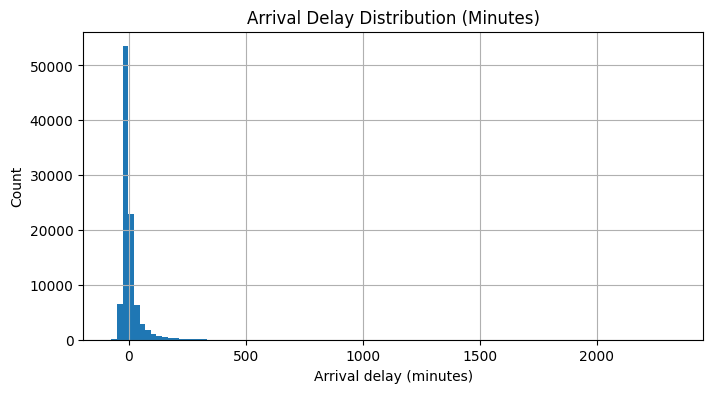

In [80]:
# Overall arrival delay distribution
df["ArrDelay"].hist(bins=100, figsize=(8, 4))
plt.title("Arrival Delay Distribution (Minutes)")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Count")
plt.show()


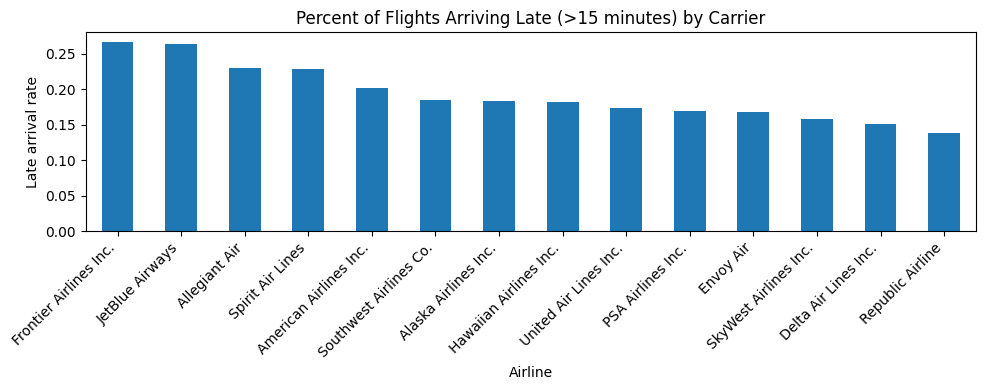

Airline
Frontier Airlines Inc.    0.266907
JetBlue Airways           0.264470
Allegiant Air             0.229995
Spirit Air Lines          0.228438
American Airlines Inc.    0.201247
Southwest Airlines Co.    0.185401
Alaska Airlines Inc.      0.184075
Hawaiian Airlines Inc.    0.182592
United Air Lines Inc.     0.173213
PSA Airlines Inc.         0.169901
Envoy Air                 0.167254
SkyWest Airlines Inc.     0.158627
Delta Air Lines Inc.      0.151080
Republic Airline          0.138742
Name: arr_late, dtype: float64

In [81]:
# Percentage of late arrivals by carrier (using 15-minute threshold)
LATE_THRESHOLD = 15
df["arr_late"] = df["ArrDelay"] > LATE_THRESHOLD

carrier_delay_rates = (
    df.groupby("Airline")["arr_late"]
      .mean()
      .sort_values(ascending=False)
)

carrier_delay_rates.plot.bar(figsize=(10, 4))
plt.title("Percent of Flights Arriving Late (>15 minutes) by Carrier")
plt.ylabel("Late arrival rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

carrier_delay_rates


### Phase 5: Transformation

We are interested in how each carrier resists cascading delays.  We'll need to do some feature transformation to help us with this analysis.

In [82]:
#Create an hour column
df["DepHour"] = df["CRSDepDateTime"].dt.hour


In [83]:
avg_delay_by_hour = (
    df.groupby(["Airline", "DepHour"])["DepDelay"]
      .mean()
      .reset_index()
)
avg_delay_by_hour

,Airline,DepHour,DepDelay
0,Alaska Airlines Inc.,0,11.812500
1,Alaska Airlines Inc.,1,-2.400000
2,Alaska Airlines Inc.,2,-5.333333
3,Alaska Airlines Inc.,3,4.000000
4,Alaska Airlines Inc.,4,NaN
...,...,...,...
289,United Air Lines Inc.,19,17.620996
290,United Air Lines Inc.,20,22.258621
291,United Air Lines Inc.,21,16.893855
292,United Air Lines Inc.,22,13.918239


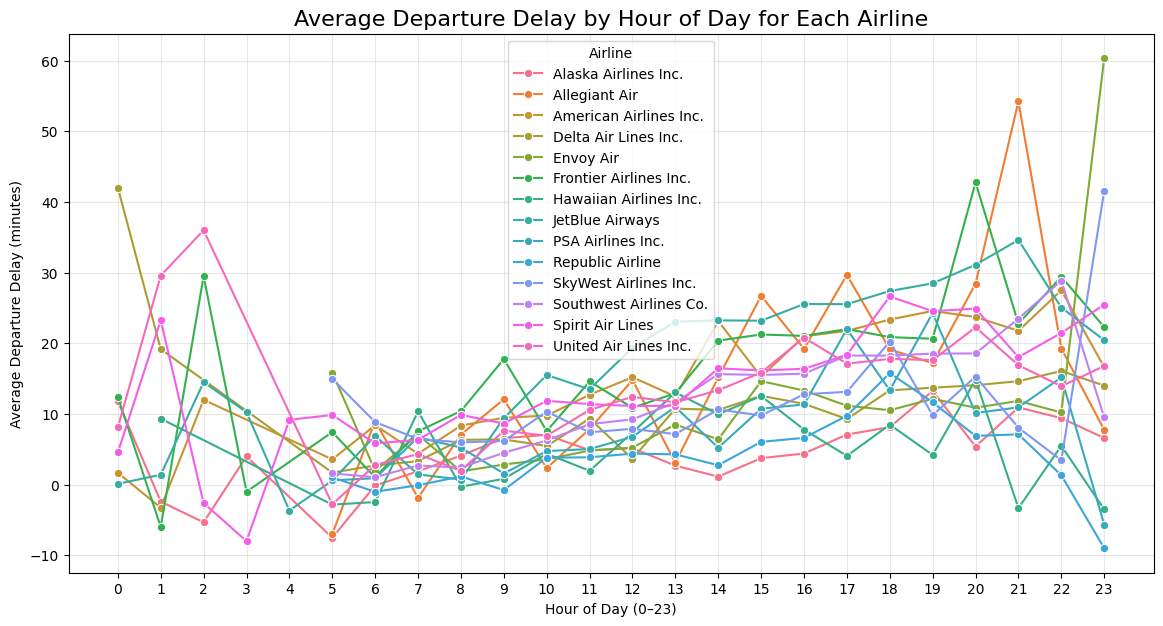

In [84]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=avg_delay_by_hour,
    x="DepHour",
    y="DepDelay",
    hue="Airline",
    marker="o"
)

plt.title("Average Departure Delay by Hour of Day for Each Airline", fontsize=16)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Departure Delay (minutes)")
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

plt.show()


It's clear in the chart above, the delays grow throughout the day for all airlines, but not at the same rate. Dispersion is smallest around 7am and grows to maximum spread at aroun 9pm. To further evaluate, we'll look at the difference in average flight delays between 7am and 9pm for each airline. **NOTE: This is  less noisy with more data**



In [85]:
subset = avg_delay_by_hour[avg_delay_by_hour["DepHour"].isin([7, 21])]

#Make 7 and 21 hours columns
pivot = subset.pivot(index="Airline", columns="DepHour", values="DepDelay")
pivot = pivot.rename(columns={7: "delay_7", 21: "delay_21"})
pivot["difference_21_minus_7"] = pivot["delay_21"] - pivot["delay_7"]
pivot

DepHour,delay_7,delay_21,difference_21_minus_7
Airline,,,
Alaska Airlines Inc.,1.889785,10.920000,9.030215
Allegiant Air,-1.878505,54.214286,56.092790
American Airlines Inc.,4.373941,21.765896,17.391955
Delta Air Lines Inc.,3.320772,14.633047,11.312275
Envoy Air,7.062745,11.841667,4.778922
Frontier Airlines Inc.,7.527273,22.768519,15.241246
Hawaiian Airlines Inc.,10.369565,-3.333333,-13.702899
JetBlue Airways,1.439024,34.620000,33.180976
PSA Airlines Inc.,6.698864,10.933333,4.234470


In [86]:
delay_diff = pivot.sort_values("difference_21_minus_7", ascending=False)
delay_diff.sort_values("difference_21_minus_7",ascending=False)


DepHour,delay_7,delay_21,difference_21_minus_7
Airline,,,
Allegiant Air,-1.878505,54.214286,56.092790
JetBlue Airways,1.439024,34.620000,33.180976
Southwest Airlines Co.,2.701005,23.491654,20.790649
American Airlines Inc.,4.373941,21.765896,17.391955
Frontier Airlines Inc.,7.527273,22.768519,15.241246
United Air Lines Inc.,4.320779,16.893855,12.573076
Spirit Air Lines,6.346939,18.032895,11.685956
Delta Air Lines Inc.,3.320772,14.633047,11.312275
Alaska Airlines Inc.,1.889785,10.920000,9.030215


Digging further, we want to see how well each airline recovers, on average, from a delayed arrival flight by seeing the average delay of departure for the same aircraft. 

In [87]:
# Sort the rows by tail number first then scheduled departure time
df = df.sort_values(["Tail_Number", "CRSDepDateTime"])

In [88]:
#Previous Flight's Arrival delay
df["PrevArrDelay"] = df.groupby("Tail_Number")["ArrDelay"].shift(1)

In [89]:
#Boolean for whether the previous flight was late more than 15 minutes
df["PrevLate"] = df["PrevArrDelay"] > 15


In [90]:
#Dleay of the next flight
df["NextDepDelay"] = df["DepDelay"]


In [91]:
#Group recoveries by carrier
recovery_by_carrier = (
    df.groupby(["Airline", "PrevLate"])["NextDepDelay"]
      .mean()
      .unstack()
)
recovery_by_carrier.columns = [
    "avg_after_on_time",
    "avg_after_late"
]
recovery_by_carrier = recovery_by_carrier.sort_values(
    "avg_after_late", ascending=False
)
recovery_by_carrier

,avg_after_on_time,avg_after_late
Airline,,
Allegiant Air,13.641374,20.940150
Frontier Airlines Inc.,16.013129,20.063934
JetBlue Airways,17.994768,19.466192
Spirit Air Lines,13.748496,18.518881
American Airlines Inc.,14.692896,17.533361
Southwest Airlines Co.,10.816285,12.703812
United Air Lines Inc.,11.405654,12.278365
SkyWest Airlines Inc.,9.585169,11.804124
Envoy Air,7.361137,9.815308


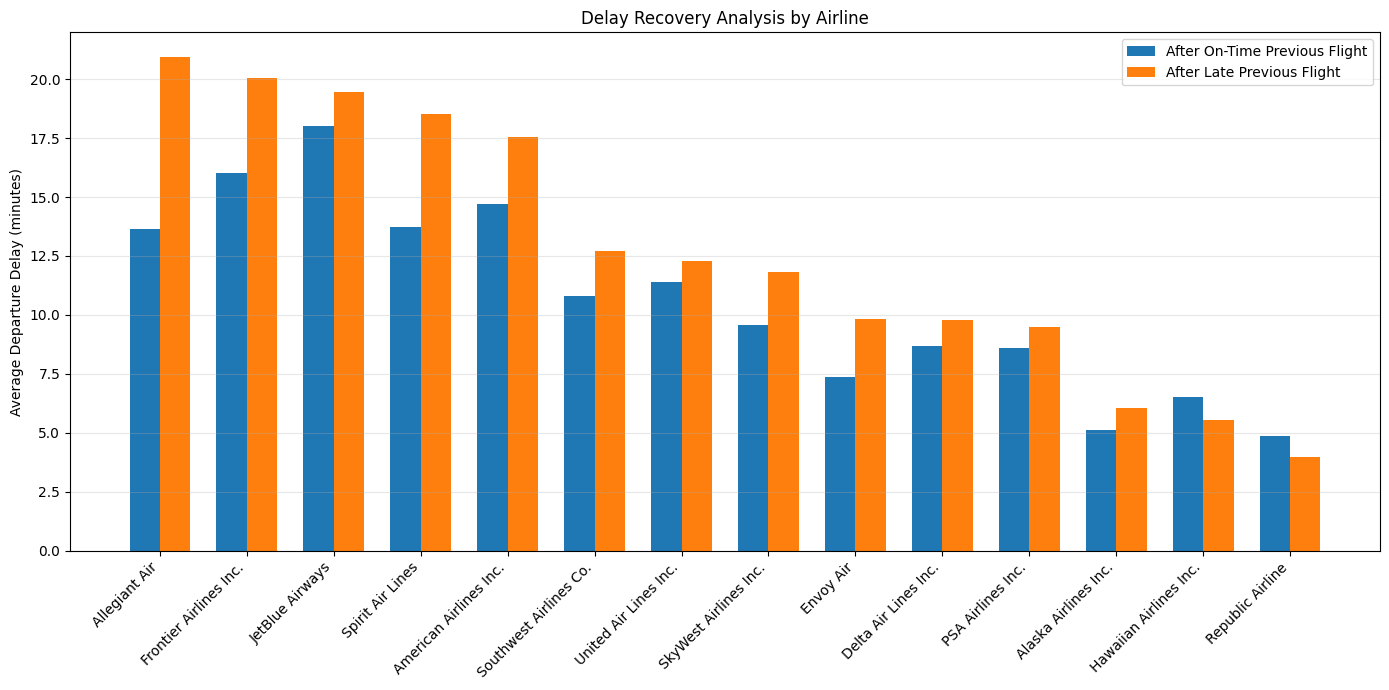

In [92]:
rc = recovery_by_carrier.copy()

x = np.arange(len(rc))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - width/2, rc["avg_after_on_time"], width, label="After On-Time Previous Flight")
ax.bar(x + width/2, rc["avg_after_late"], width, label="After Late Previous Flight")

ax.set_xticks(x)
ax.set_xticklabels(rc.index, rotation=45, ha="right")
ax.set_ylabel("Average Departure Delay (minutes)")
ax.set_title("Delay Recovery Analysis by Airline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### Phase 6: Save and Document

We can conclude from this analysis that time of day and choice of carrier play a meaningful role in likelihood of delay.  Mornings flights with reputable air carriers like Southwest are your best bet.